In [4]:
! pip install datasets transformers accelerate

In [5]:


# from huggingface_hub import notebook_login

# notebook_login()


In [6]:
# !curl google.com

In [7]:
import transformers

print(transformers.__version__)

5.0.0


## task

In [8]:
task = "cola"
model_checkpoint = "distilbert-base-uncased"
batch_size = 16

## load dataset and evaluation metric

In [9]:
from datasets import load_dataset

In [10]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00


In [11]:
import evaluate

In [12]:
actual_task = "mnli" if task == "mnli-mm" else task
dataset = load_dataset("glue", actual_task)
metric = evaluate.load("glue", actual_task)

README.md: 0.00B [00:00, ?B/s]

cola/train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

cola/validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

cola/test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]

In [13]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})

In [14]:
dataset["train"][0]

{'sentence': "Our friends won't buy this analysis, let alone the next one we propose.",
 'label': 1,
 'idx': 0}

In [15]:
metric

EvaluationModule(name: "glue", module_type: "metric", features: {'predictions': Value('int64'), 'references': Value('int64')}, usage: """
Compute GLUE evaluation metric associated to each GLUE dataset.
Args:
    predictions: list of predictions to score.
        Each translation should be tokenized into a list of tokens.
    references: list of lists of references for each translation.
        Each reference should be tokenized into a list of tokens.
Returns: depending on the GLUE subset, one or several of:
    "accuracy": Accuracy
    "f1": F1 score
    "pearson": Pearson Correlation
    "spearmanr": Spearman Correlation
    "matthews_correlation": Matthew Correlation
Examples:

    >>> glue_metric = evaluate.load('glue', 'sst2')  # 'sst2' or any of ["mnli", "mnli_mismatched", "mnli_matched", "qnli", "rte", "wnli", "hans"]
    >>> references = [0, 1]
    >>> predictions = [0, 1]
    >>> results = glue_metric.compute(predictions=predictions, references=references)
    >>> print(results

In [16]:
dataset["train"][[0,2,4]]

{'sentence': ["Our friends won't buy this analysis, let alone the next one we propose.",
  "One more pseudo generalization or I'm giving up.",
  'Day by day the facts are getting murkier.'],
 'label': [1, 1, 1],
 'idx': [0, 2, 4]}

In [17]:
import datasets
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)
    
    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, datasets.ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
    display(HTML(df.to_html()))



In [18]:
show_random_elements(dataset["train"])

,sentence,label,idx
0,They've got it made.,acceptable,2531
1,On the line there are drying a lot of clothes.,unacceptable,3271
2,"As it rains harder, how much faster a flow that appears in the river?",unacceptable,126
3,I am removing the shovel from the shed.,acceptable,4549
4,He's as reliable a man.,acceptable,5442
5,I had hoped that it was true that Rosa Luxemburg had actually defected to Iceland for many years.,acceptable,6582
6,I put a book on it.,acceptable,5907
7,Carmen obtained Mary a spare part.,unacceptable,2748
8,John sang beautifully.,acceptable,7000
9,Jack eats caviar more than he sleeps.,acceptable,5338


In [19]:
dataset["train"].features.items()

dict_items([('sentence', Value('string')), ('label', ClassLabel(names=['unacceptable', 'acceptable'])), ('idx', Value('int32'))])

In [20]:

import numpy as np

fake_preds = np.random.randint(0, 2, size=(64,))
fake_labels = np.random.randint(0, 2, size=(64,))
# metric.compute(predictions=fake_preds, references=fake_preds)

metric.compute(predictions=fake_preds, references=fake_labels)

{'matthews_correlation': np.float64(-0.0629940788348712)}

## Preprocessing

In [21]:


from transformers import AutoTokenizer
    
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [22]:
tokenizer("Hello, this one sentence!", "And this sentence goes with it.")

{'input_ids': [101, 7592, 1010, 2023, 2028, 6251, 999, 102, 1998, 2023, 6251, 3632, 2007, 2009, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [23]:
tokenizer("Hello, this one sentence this is again!")

{'input_ids': [101, 7592, 1010, 2023, 2028, 6251, 2023, 2003, 2153, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [24]:
token = tokenizer.convert_ids_to_tokens([101, 7592, 1010, 2023, 2028, 6251, 999, 102, 1998, 2023, 6251, 3632, 2007, 2009, 1012, 102])
token

['[CLS]',
 'hello',
 ',',
 'this',
 'one',
 'sentence',
 '!',
 '[SEP]',
 'and',
 'this',
 'sentence',
 'goes',
 'with',
 'it',
 '.',
 '[SEP]']

In [25]:


task_to_keys = {
    "cola": ("sentence", None),
    "mnli": ("premise", "hypothesis"),
    "mnli-mm": ("premise", "hypothesis"),
    "mrpc": ("sentence1", "sentence2"),
    "qnli": ("question", "sentence"),
    "qqp": ("question1", "question2"),
    "rte": ("sentence1", "sentence2"),
    "sst2": ("sentence", None),
    "stsb": ("sentence1", "sentence2"),
    "wnli": ("sentence1", "sentence2"),
}



In [26]:
sentence1_key, sentence2_key = task_to_keys[task]
if sentence2_key is None:
    print(f"Sentence: {dataset['train'][0][sentence1_key]}")
else:
    print(f"Sentence 1: {dataset['train'][0][sentence1_key]}")
    print(f"Sentence 2: {dataset['train'][0][sentence2_key]}")

Sentence: Our friends won't buy this analysis, let alone the next one we propose.


In [27]:

def preprocess_function(examples):
    if sentence2_key is None:
        return tokenizer(examples[sentence1_key], truncation=True)
    return tokenizer(examples[sentence1_key], examples[sentence2_key], truncation=True)



In [28]:
preprocess_function(dataset['train'][:5])

{'input_ids': [[101, 2256, 2814, 2180, 1005, 1056, 4965, 2023, 4106, 1010, 2292, 2894, 1996, 2279, 2028, 2057, 16599, 1012, 102], [101, 2028, 2062, 18404, 2236, 3989, 1998, 1045, 1005, 1049, 3228, 2039, 1012, 102], [101, 2028, 2062, 18404, 2236, 3989, 2030, 1045, 1005, 1049, 3228, 2039, 1012, 102], [101, 1996, 2062, 2057, 2817, 16025, 1010, 1996, 13675, 16103, 2121, 2027, 2131, 1012, 102], [101, 2154, 2011, 2154, 1996, 8866, 2024, 2893, 14163, 8024, 3771, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [29]:
encoded_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/8551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1043 [00:00<?, ? examples/s]

Map:   0%|          | 0/1063 [00:00<?, ? examples/s]

## Fine Tuning

In [30]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

num_labels = 3 if task.startswith("mnli") else 1 if task=="stsb" else 2
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
metric_name = "pearson" if task == "stsb" else "matthews_correlation" if task == "cola" else "accuracy"
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"{model_name}-finetuned-{task}",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model=metric_name,
)

In [36]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if task != "stsb":
        predictions = np.argmax(predictions, axis=1)
    else:
        predictions = predictions[:, 0]
    return metric.compute(predictions=predictions, references=labels)

In [37]:

validation_key = "validation_mismatched" if task == "mnli-mm" else "validation_matched" if task == "mnli" else "validation"
trainer = Trainer(
    model,
    args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset[validation_key],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)



In [38]:

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Matthews Correlation
1,No log,0.933572,0.476126
2,0.903337,0.967791,0.510895
3,0.903337,1.089373,0.511326
4,0.465177,1.207361,0.532110
5,0.465177,1.262276,0.541357


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1340, training_loss=0.5878346172731315, metrics={'train_runtime': 145.4157, 'train_samples_per_second': 294.019, 'train_steps_per_second': 9.215, 'total_flos': 255059507977428.0, 'train_loss': 0.5878346172731315, 'epoch': 5.0})

In [39]:


trainer.evaluate()



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.2622758150100708,
 'eval_matthews_correlation': 0.541356878970505,
 'eval_runtime': 1.3307,
 'eval_samples_per_second': 783.784,
 'eval_steps_per_second': 24.799,
 'epoch': 5.0}

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
history.head()

,eval_loss,eval_matthews_correlation,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step,loss,grad_norm,learning_rate,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.933572,0.476126,1.2814,813.977,25.754,1.000000,268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,1.865672,500,0.903337,17.563768,0.000013,NaN,NaN,NaN,NaN,NaN
2,0.967791,0.510895,1.2738,818.807,25.907,2.000000,536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.089373,0.511326,1.2769,816.838,25.844,3.000000,804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.731343,1000,0.465177,17.678921,0.000005,NaN,NaN,NaN,NaN,NaN


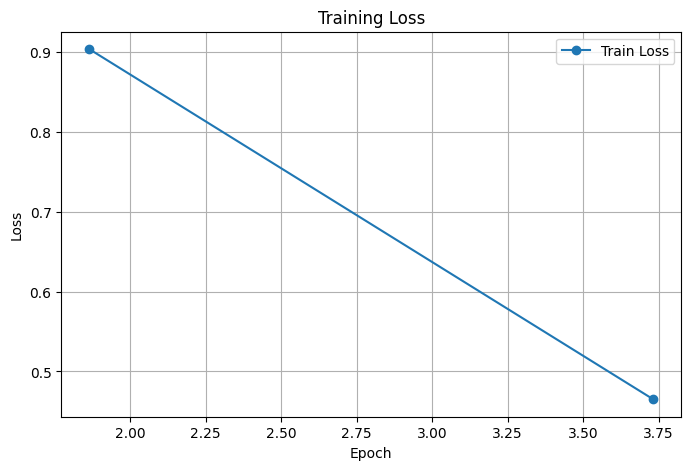

In [42]:
train_logs = history.dropna(subset=["loss"])

plt.figure(figsize=(8,5))

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    label="Train Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

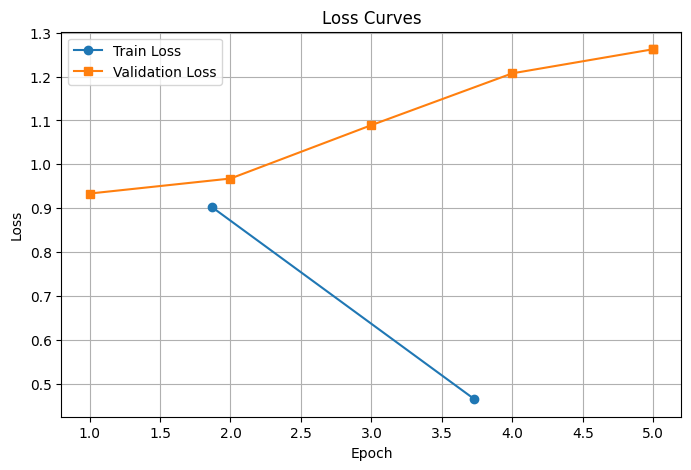

In [43]:
plt.figure(figsize=(8,5))

train_logs = history.dropna(subset=["loss"])
eval_logs = history.dropna(subset=["eval_loss"])

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

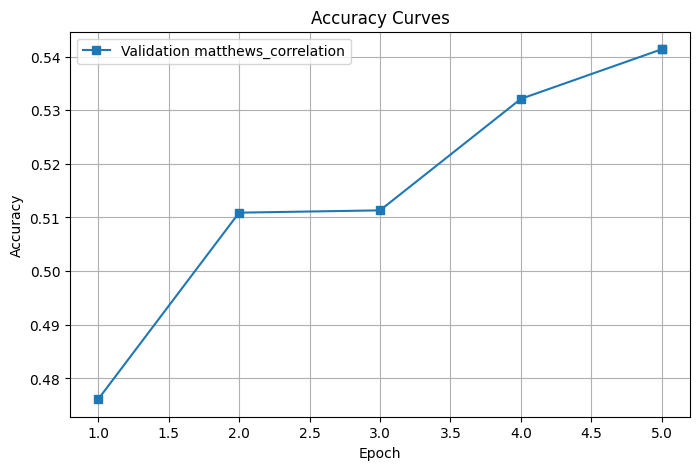

In [47]:
plt.figure(figsize=(8,5))

eval_logs = history.dropna(subset=["eval_matthews_correlation"])


plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_matthews_correlation"],
    marker="s",
    label="Validation matthews_correlation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer
)

texts = [
    "This movie was fantastic!",
    "I hates every minute of."
]

for text in texts:
    result = classifier(text)
    print(text)
    print(result)
    print()

This movie was fantastic!
[{'label': 'LABEL_1', 'score': 0.9910877346992493}]

I hates every minute of.
[{'label': 'LABEL_0', 'score': 0.946031391620636}]



### hyperparameter search

In [ ]:
! pip install optuna
! pip install ray[tune]

In [ ]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

In [ ]:


trainer = Trainer(
    model_init=model_init,
    args=args,
    train_dataset = encoded_dataset["train"].shard(index=1, num_shards=10),
    eval_dataset=encoded_dataset[validation_key],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)



In [ ]:
best_run = trainer.hyperparameter_search(n_trials=10, direction="maximize")

In [ ]:
best_run

In [ ]:
for n, v in best_run.hyperparameters.items():
    setattr(trainer.args, n, v)

trainer.train()